In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("13-seismic_activity_svm.csv")

In [3]:
df.head()

,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


In [5]:
X = df.drop(['seismic_event_detected'], axis = 1).values
y = df['seismic_event_detected'].values

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
X_train = torch.tensor(X_train, dtype = torch.float32)
X_test = torch.tensor(X_test, dtype = torch.float32)

y_train = torch.tensor(y_train, dtype = torch.float32)
y_test = torch.tensor(y_test, dtype = torch.float32)

In [9]:
X_train.shape, y_train.shape

(torch.Size([320, 2]), torch.Size([320]))

In [10]:
y_train = y_train.unsqueeze(dim = 1)
y_test = y_test.unsqueeze(dim = 1)

In [11]:
X_train.shape, y_train.shape

(torch.Size([320, 2]), torch.Size([320, 1]))

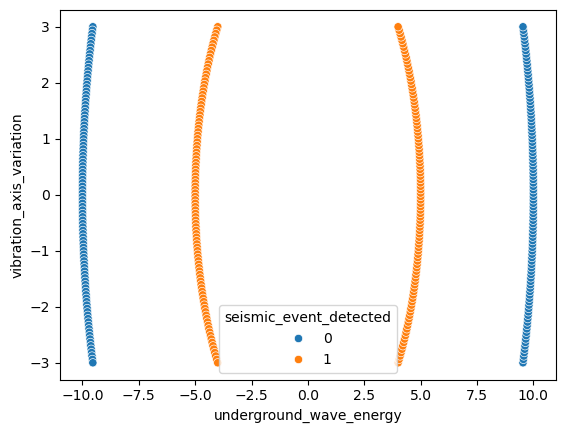

In [12]:
sns.scatterplot(data = df, x = 'underground_wave_energy', y = 'vibration_axis_variation', hue = 'seismic_event_detected')
plt.show()

In [13]:
from torch import nn
class ClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

In [14]:
model_0 = ClassificationModel()

In [15]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(
    params = model_0.parameters(),
    lr = 0.001
)

In [16]:
def calculate_accuracy(y_pred, y_test):
    correct = torch.eq(y_pred, y_test).sum().item()
    accuracy = (correct / len(y_pred)) * 100
    return accuracy

In [17]:
torch.manual_seed(42)
epochs = 450

for epoch in range(epochs):
    model_0.train()
    # 1. Forward Pass
    y_logits = model_0(X_train)
    y_preds = torch.round(torch.sigmoid(y_logits))
    # 2. Calculate Loss
    loss = loss_fn(y_logits, y_train)
    acc = calculate_accuracy(y_preds, y_train)
    # 3. Optimizer Zero Grad
    optimizer.zero_grad()
    # 4. Loss Backward
    loss.backward()
    # 5. Optimizer Step
    optimizer.step()

    model_0.eval()

    with torch.inference_mode():
        test_logits = model_0(X_test)
        test_preds = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = calculate_accuracy(test_preds, y_test)

    if epoch % 50 == 0:
        print(f"Epoch: {epoch} | Train Loss: {loss:.5f} | Train Acc: {acc:.2f} | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}")

Epoch: 0 | Train Loss: 0.70698 | Train Acc: 51.88 | Test Loss: 0.69753 | Test Acc: 57.50
Epoch: 50 | Train Loss: 0.67704 | Train Acc: 54.37 | Test Loss: 0.67558 | Test Acc: 56.25
Epoch: 100 | Train Loss: 0.63899 | Train Acc: 74.69 | Test Loss: 0.64510 | Test Acc: 78.75
Epoch: 150 | Train Loss: 0.56658 | Train Acc: 77.81 | Test Loss: 0.58641 | Test Acc: 80.00
Epoch: 200 | Train Loss: 0.47575 | Train Acc: 81.88 | Test Loss: 0.50149 | Test Acc: 85.00
Epoch: 250 | Train Loss: 0.39746 | Train Acc: 89.06 | Test Loss: 0.42896 | Test Acc: 90.00
Epoch: 300 | Train Loss: 0.31687 | Train Acc: 95.62 | Test Loss: 0.35668 | Test Acc: 93.75
Epoch: 350 | Train Loss: 0.24640 | Train Acc: 98.75 | Test Loss: 0.29049 | Test Acc: 98.75
Epoch: 400 | Train Loss: 0.20002 | Train Acc: 100.00 | Test Loss: 0.24567 | Test Acc: 98.75


In [20]:
def plot_decision_boundary(model, X, y):
    """
    Modelin 2 boyutlu uzayda yaptığı ayrımı görselleştirir.
    
    Parametreler:
    model: Eğitilmiş PyTorch modeli
    X: 2 boyutlu özellik tensörü (ör. X_train veya X_test)
    y: Etiket tensörü (ör. y_train veya y_test)
    """
    # Verileri CPU'ya ve numpy dizilerine çeviriyoruz
    X_np = X.cpu().detach().numpy()
    y_np = y.cpu().detach().numpy().squeeze()
    
    # Eksen sınırlarını belirliyoruz (Kenarlarda biraz boşluk bırakarak)
    x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
    y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5
    
    # Tüm düzlemi kaplayacak bir ızgara (meshgrid) oluşturuyoruz
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                         np.linspace(y_min, y_max, 100))
    
    # Izgaradaki noktaları modelin alabileceği tensör formatına getiriyoruz
    X_grid = np.c_[xx.ravel(), yy.ravel()]
    X_grid_tensor = torch.from_numpy(X_grid).float()
    
    # Modelin üzerinde olduğu cihaza (CPU/GPU) grid'i de gönderelim
    device = next(model.parameters()).device
    X_grid_tensor = X_grid_tensor.to(device)
    
    # Modeli değerlendirme moduna alıp tüm düzlem için tahmin yapıyoruz
    model.eval()
    with torch.inference_mode():
        # Senin yazdığın yapıya uygun olarak: Logits -> Sigmoid -> Round
        grid_logits = model(X_grid_tensor)
        grid_preds = torch.round(torch.sigmoid(grid_logits))
        
    # Tahminleri görselleştirme için ızgara boyutuna geri boyutlandırıyoruz
    grid_preds = grid_preds.cpu().numpy().reshape(xx.shape)
    
    # Grafiği çizdirme zamanı
    plt.figure(figsize=(10, 6))
    
    # 1. Arka planı tahminlere göre boyama (Karar Sınırı)
    plt.contourf(xx, yy, grid_preds, alpha=0.3, cmap='bwr')
    
    # 2. Gerçek veri noktalarını çizdirme (Seaborn kullanarak)
    sns.scatterplot(
        x=X_np[:, 0], 
        y=X_np[:, 1], 
        hue=y_np, 
        palette='bwr', 
        edgecolor='black', 
        s=60
    )
    
    plt.title("Model Karar Sınırı (Decision Boundary)")
    plt.xlabel("Özellik 1 (Feature 1)")
    plt.ylabel("Özellik 2 (Feature 2)")
    plt.legend(title="Sınıflar")
    plt.show()

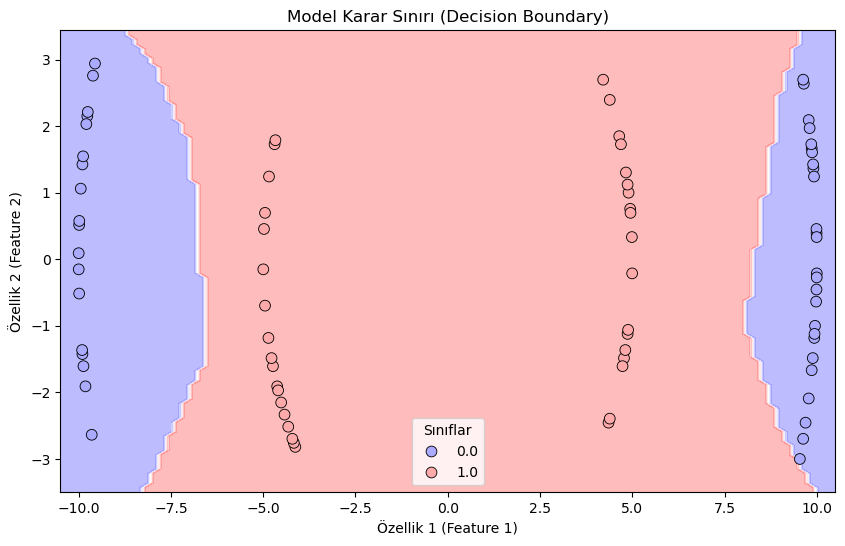

In [21]:
plot_decision_boundary(model_0, X_test, y_test)